# Exploratory Data Analysis for Subway Ridership Forecasting

This notebook performs Exploratory Data Analysis for the Subway Ridership Forecasting Capstone Project. In this notebook, we'll start to understand the structure, quality, and behavior of our dataset. We can examine patterns, distributions, correlations, and any anomalies that present themselves. This way we can generate a hypothesis for our subway ridership, and model it in the next step.


## Imports we might use

In [17]:
#All datascience imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

In [ ]:
#Function to load CSV
def load_csv(file_name):
    """
    Load a CSV file from the 'CSVs' folder into a pandas DataFrame.
    """
    try:
        file_path = os.path.join("..", "CSVs", file_name)
        df = pd.read_csv(file_path)
        print(f"CSV file '{file_path}' loaded successfully.")
        return df
    except Exception as e:
        print(f"Error loading CSV file: {e}")
        return None

These functions are starter functions that help us get through most of the statistics.
But lets get started into what our primary objectives this notebook are:

1) Understanding the Data
2) Exploring the Relationships Between Data
3) Feature Selection and Engineering




## Understanding the Data

Let's take a look at our preprocessed data and wide data to see which is going to be the most applicable here.

In [19]:
processed_data = load_csv("processed_data.csv")
wide_data = load_csv("wide_data.csv")

print(processed_data.head())
print("\n", wide_data.head())

C:\Users\Esh\AppData\Local\Temp\ipykernel_31332\3908567062.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


CSV file '..\CSVs\processed_data.csv' loaded successfully.


C:\Users\Esh\AppData\Local\Temp\ipykernel_31332\3908567062.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


CSV file '..\CSVs\wide_data.csv' loaded successfully.
  station_id                     station borough            timestamp  \
0          1  Astoria-Ditmars Blvd (N,W)  Queens  2022-05-18 00:00:00   
1          1  Astoria-Ditmars Blvd (N,W)  Queens  2022-05-18 01:00:00   
2          1  Astoria-Ditmars Blvd (N,W)  Queens  2022-05-18 02:00:00   
3          1  Astoria-Ditmars Blvd (N,W)  Queens  2022-05-18 03:00:00   
4          1  Astoria-Ditmars Blvd (N,W)  Queens  2022-05-18 04:00:00   

   ridership_total  ridership  ridership_omny  hour  day  day_of_week  month  \
0               42       27.0            15.0     0   18            2      5   
1               11        9.0             2.0     1   18            2      5   
2                5        4.0             1.0     2   18            2      5   
3               20       15.0             5.0     3   18            2      5   
4               57       41.0            16.0     4   18            2      5   

   year  is_weekend  is_ho

We'll stick with the processed_data as it allows us to easily select features to hypothesize from.

In [20]:
# Basic information about the loaded dataset.
print("Shape (rows, columns):", processed_data.shape)

# Data types and non-null counts per column
print("\nInfo for processed_data:")
processed_data.info()

Shape (rows, columns): (7614788, 14)

Info for processed_data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7614788 entries, 0 to 7614787
Data columns (total 14 columns):
 #   Column           Dtype  
---  ------           -----  
 0   station_id       object 
 1   station          object 
 2   borough          object 
 3   timestamp        object 
 4   ridership_total  int64  
 5   ridership        float64
 6   ridership_omny   float64
 7   hour             int64  
 8   day              int64  
 9   day_of_week      int64  
 10  month            int64  
 11  year             int64  
 12  is_weekend       int64  
 13  is_holiday       int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 813.3+ MB


**processed_data** contains 7614788 rows and 14 columns. These columns include the station metadata (`station_id`, `station`, `borough`), ridership metrics (`ridership_total`, `ridership`, `ridership_omny`), and calendar features (`timestamp`, `hour`, `day`, `day_of_week`, `month`, `year`, `is_weekend`, `is_holiday`)

In [21]:
# Let's make a proper date column to be able to select the feature as a daily time series
processed_data['date'] = pd.to_datetime(processed_data['timestamp']).dt.date

# Let's also look at the date range
print("\nDate range:", processed_data['timestamp'].min(), "to", processed_data['timestamp'].max())


Date range: 2022-05-15 09:00:00 to 2024-05-20 08:00:00


In [22]:
# Quick look at unique station_id values
num_stations = processed_data['station_id'].nunique()
print("Unique station_id values:", num_stations)

# Quick look at borough distribution
print("\nBorough value counts:")
print(processed_data['borough'].value_counts())

# Fraction of missing values per column
missing_fraction = processed_data.isna().mean().sort_values(ascending=False)
print("\nMissing fraction per column (highest first):")
print(missing_fraction)

Unique station_id values: 431

Borough value counts:
borough
Brooklyn         2766451
Manhattan        2198612
Queens           1401724
Bronx            1214039
Staten Island      33962
Name: count, dtype: int64

Missing fraction per column (highest first):
ridership_omny     0.060585
ridership          0.007824
station_id         0.000000
station            0.000000
borough            0.000000
timestamp          0.000000
ridership_total    0.000000
hour               0.000000
day                0.000000
day_of_week        0.000000
month              0.000000
year               0.000000
is_weekend         0.000000
is_holiday         0.000000
date               0.000000
dtype: float64


### Data Coverage and Quality

This dataset includes subway ridership activity for 431 unique stations across New York City. All five boroughs are represented. Most of the data comes from Brooklyn (~2.77M rows), followed by Manhattan (~2.20M), Queens (~1.40M), the Bronx (~1.21M), and then Staten Island (~34K). So the coverage is citywide, but it’s clearly weighted toward the systems with more inferred volume (Brooklyn and Manhattan) and much lighter in Staten Island.

After converting `timestamp` to a datetime and adding a `date` column, the data ranges from 2022-05-15 09:00:00 through 2024-05-20 08:00:00. That’s the window we’ll be working in when we look for trends, seasonality, and other changes over time.

Core fields are in good shape. Keys like `station_id`, `station`, and `borough` are complete, and `ridership_total` (which we’ll treat as the main target) has no missing values. The time/context fields (`timestamp`, `hour`, `day`, `day_of_week`, `month`, `year`) and the flags (`is_weekend`, `is_holiday`) are also fully populated. That means we can group and compare ridership across stations, boroughs, weekdays vs weekends, and holidays without immediately losing data.

Some supporting fields are not fully complete. `ridership` (MetroCard) is missing in about 0.78% of rows and `ridership_omny` (OMNY taps) is missing in about 6.06% of rows. This is probably a reporting/availability issue rather than a coding error, and it mostly affects how confidently we can talk about OMNY adoption. Since `ridership_total` is present everywhere, we can still use `ridership_total` as the modeling target. For OMNY-specific analysis, we’ll either work only on rows where OMNY data exists, or add an indicator to mark “OMNY not reported here.”

Bottom line: the main target (`ridership_total`) is clean, the time span is about two years, and coverage is broad enough (across boroughs and stations) to analyze ridership patterns at both the city level and station level.

In [23]:
# Aggregate hourly rows into daily totals per station
daily = (
    processed_data
        .groupby(['station_id', 'station', 'borough', 'date'])
        [['ridership_total', 'ridership', 'ridership_omny']]
        .sum()
        .reset_index()
)

# Make sure 'date' is a real datetime, not just an object
daily['date'] = pd.to_datetime(daily['date'], errors='raise')

print("Daily shape (rows, columns):", daily.shape)
print(daily.head())


Daily shape (rows, columns): (315135, 7)
  station_id                     station borough       date  ridership_total  \
0          1  Astoria-Ditmars Blvd (N,W)  Queens 2022-05-15             4584   
1          1  Astoria-Ditmars Blvd (N,W)  Queens 2022-05-16             9224   
2          1  Astoria-Ditmars Blvd (N,W)  Queens 2022-05-17            10571   
3          1  Astoria-Ditmars Blvd (N,W)  Queens 2022-05-18            10714   
4          1  Astoria-Ditmars Blvd (N,W)  Queens 2022-05-19            10201   

   ridership  ridership_omny  
0     2827.0          1757.0  
1     6480.0          2744.0  
2     7234.0          3337.0  
3     7313.0          3401.0  
4     6944.0          3257.0  


Each row in `daily` represents one station on one calendar date, with total ridership for that station on that date. This will be the unit used for modeling

### Hypothesis Formation

Before getting into formal statistical tests, I want to check some patterns that look important for forecasting ridership. Below are the main questions I plan to investigate, along with the null and alternative hypotheses I’ll test later.

#### 1. Weekday vs. Weekend ridership

**Null**: Average daily ridership is the same on weekdays and weekends.

**Alternative**: Average daily ridership is different on weekdays than on weekends.

**Why I care**: If weekend behavior is consistently lower (or higher), then a simple weekend/weekday flag should be a useful feature in the model.

#### 2. Holiday effect

**Null**: Average daily ridership on holidays is the same as on non-holidays.

**Alternative**: Average daily ridership on holidays is different from non-holidays.

**Why I care**: Holidays might behave like “special cases.” If ridership reliably drops for holidays, I should include a holiday indicator so the model doesn’t over-predict on those days.

#### 3. Borough differences

**Null**: All boroughs have the same mean daily ridership.

**Alternative**: At least one borough’s mean daily ridership is different from the others.

**Why I care**: If certain boroughs have consistently higher or lower station traffic, then borough (or something like station location) should be treated as a real predictive feature, not just metadata.

#### 4. OMNY adoption / payment behavior

**Null**: The share of OMNY usage (`ridership_omny` / `ridership_total`) is the same across boroughs.

**Alternative**: OMNY share is different across boroughs.

**Why I care**: This could matter for modeling demand and for understanding how ridership is changing over time.




## Exploring the Relationships Between Data





### 1. Weekday vs Weekend Ridership

In [24]:
daily['date'] = pd.to_datetime(daily['date'], errors='coerce')
daily['day_name'] = daily['date'].dt.day_name()
daily['is_weekend'] = daily['day_name'].isin(['Saturday', 'Sunday'])

# Mean/std/count for each day of week
weekday_summary = (
    daily
    .groupby('day_name')['ridership_total']
    .agg(['mean', 'std', 'count'])
    .sort_values('mean', ascending=False)
)

print("Daily ridership by weekday:")
print(weekday_summary)

weekend_summary = (
    daily
    .groupby('is_weekend')['ridership_total']
    .agg(['mean', 'std', 'count'])
    .rename(index={False: 'Weekday', True: 'Weekend'})
)

print("\nWeekend vs Weekday ridership:")
print(weekend_summary)

Daily ridership by weekday:
                  mean           std  count
day_name                                   
Wednesday  8724.570739  12545.089983  44947
Thursday   8636.483603  12361.864166  44948
Tuesday    8483.434932  12206.732641  44961
Friday     8003.601388  10964.414023  44956
Monday     7315.565742  10348.128459  45367
Saturday   5432.463362   8334.737811  44790
Sunday     4312.216955   6676.468672  45166

Weekend vs Weekday ridership:
                   mean           std   count
is_weekend                                   
Weekday     8231.028822  11726.676060  225179
Weekend     4869.998944   7568.528414   89956


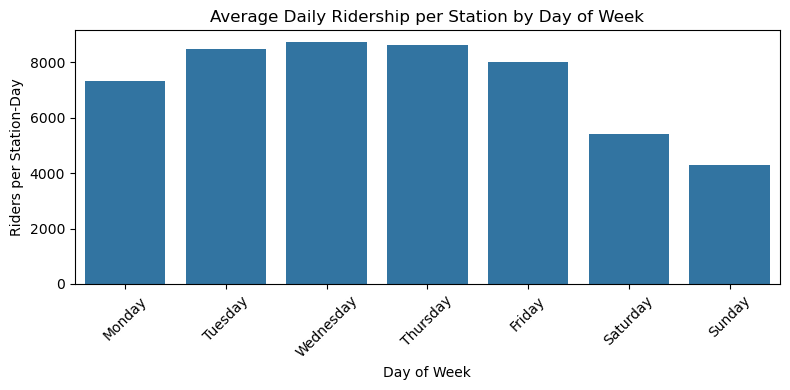

In [31]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

avg_by_day = (
    daily.groupby('day_name')['ridership_total']
    .mean()
    .reindex(day_order)
    .reset_index()
)

plt.figure(figsize=(8,4))
sns.barplot(
    data=avg_by_day,
    x='day_name',
    y='ridership_total'
)
plt.title('Average Daily Ridership per Station by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Riders per Station-Day')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Weekday ridership is clearly higher than weekend ridership. On weekdays, the average station-day ridership is about **8,231** riders with a standard deviation of about **11,727** across **225,179** station-days. On weekends, the average drops to about **4,870** riders with a lower standard deviation of about **7,569** across **89,956** station-days.

Looking at individual days of the week, Tuesday/Wednesday/Thursday are the strongest ridership days (Wednesday is highest at ~**8,725** riders per station-day on average), and Sunday is the lowest (~**4,312**). This is exactly what you’d expect in a commuter-centric city: midweek is peak usage, Sunday is quiet.

So we can finalize that there is a strong weekday vs weekend effect, and this implies that we can use `is_weekend` (or potentially  `day_of_week`) as a feature for our model.


### 2. Holiday vs Non-Holiday Ridership

In [25]:
processed_data['timestamp'] = pd.to_datetime(processed_data['timestamp'], errors='coerce')
processed_data['date'] = pd.to_datetime(processed_data['timestamp'].dt.date, errors='coerce')

daily['date'] = pd.to_datetime(daily['date'], errors='coerce')

holiday_flag = (
    processed_data
        .groupby(['station_id', 'date'])['is_holiday']
        .max()
        .reset_index()
        .rename(columns={'is_holiday': 'is_holiday_day'})
)

daily = daily.merge(holiday_flag, on=['station_id', 'date'], how='left')

holiday_summary = (
    daily
        .groupby('is_holiday_day')['ridership_total']
        .agg(['mean', 'std', 'count'])
        .rename(index={0: 'Non-holiday', 1: 'Holiday'})
)

print("Holiday vs Non-Holiday ridership:")
print(holiday_summary)

Holiday vs Non-Holiday ridership:
                       mean           std   count
is_holiday_day                                   
Non-holiday     7359.929883  10905.219296  304022
Holiday         4855.562044   7480.087856   11113


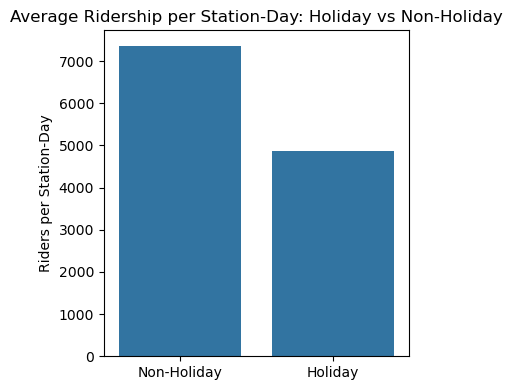

In [ ]:
holiday_summary_plot = (
    daily
    .groupby('is_holiday_day')['ridership_total']
    .mean()
    .rename({0: 'Non-Holiday', 1: 'Holiday'})
    .reset_index()
    .rename(columns={'is_holiday_day':'day_type','ridership_total':'avg_riders'})
)

plt.figure(figsize=(4,4))
sns.barplot(
    data=holiday_summary_plot,
    x='day_type',
    y='avg_riders'
)
plt.title('Average Ridership per Station-Day: Holiday vs Non-Holiday')
plt.xlabel('')
plt.ylabel('Riders per Station-Day')
plt.tight_layout()
plt.show()

Holidays behave differently from normal days. On non-holidays, average ridership per station-day is about **7,360** riders with a standard deviation of about **10,905**, based on **304,022** station-days. On holidays, that average falls to about **4,856** riders, with a standard deviation of about **7,480**, across **11,113** station-days.

So, on holidays, stations are seeing thousands fewer riders on average than they do on regular days. This drop justifies `is_holiday` becoming a feature for our model as well.


### 3. Ridership by Borough

In [11]:
borough_summary = (
    daily
    .groupby('borough')['ridership_total']
    .agg(['mean', 'std', 'count'])
    .sort_values('mean', ascending=False)
)

print("Ridership by borough (per station-day):")
print(borough_summary)

Ridership by borough (per station-day):
                       mean           std   count
borough                                          
Manhattan      13957.067359  16791.959538   90604
Queens          5894.764402   7259.958915   58116
Brooklyn        4483.635100   4204.187624  114837
Bronx           3301.411216   2526.024353   50105
Staten Island   2776.505092   2923.112719    1473


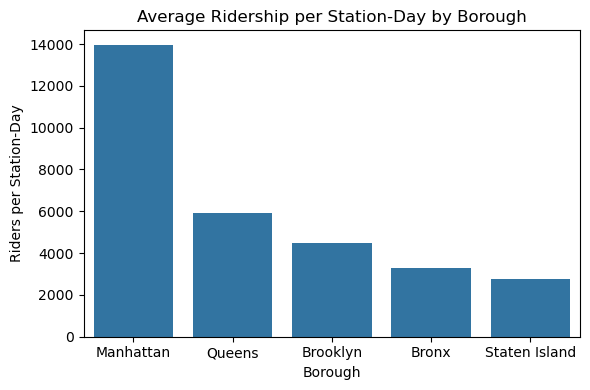

In [ ]:
borough_summary_plot = (
    daily
    .groupby('borough')['ridership_total']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'ridership_total':'avg_ridership'})
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=borough_summary_plot,
    x='borough',
    y='avg_ridership'
)
plt.title('Average Ridership per Station-Day by Borough')
plt.xlabel('Borough')
plt.ylabel('Riders per Station-Day')
plt.tight_layout()
plt.show()

As expected, ridership is not uniform across boroughs. 

Manhattan stations average about **13,957** riders per station-day, with a high spread (std ~**16,792**) across **90,604** station-days. Queens stations average about **5,895** riders, std ~**7,260**, across **58,116** station-days. Brooklyn stations average about **4,484** riders, std ~**4,204**, across **114,837** station-days. The Bronx averages about **3,301** riders, std ~**2,526**, across **50,105** station-days. Staten Island is the lowest at about **2,777** riders, std ~**2,923**, across **1,473** station-days.

Manhattan is a clear outlier on the high end with roughly **3x** to **5x** the per-station traffic of the Bronx or Staten Island. The fact that Manhattan also has a large standard deviation suggests it has both massive hub stations and smaller/less-trafficked stations.

This tells that `borough` is a real feature and that it should be encoded. We also realize that every station differs: high std and differences in borough shough that every location changes its baseline.


### 4. OMNY Adoption by Borough

In [12]:
daily['omny_share'] = daily['ridership_omny'] / daily['ridership_total']

omny_summary = (
    daily
    .groupby('borough')['omny_share']
    .agg(['mean', 'std', 'count'])
    .sort_values('mean', ascending=False)
)

print("OMNY share by borough:")
print(omny_summary)


OMNY share by borough:
                   mean       std   count
borough                                  
Manhattan      0.466989  0.119735   90604
Brooklyn       0.396483  0.133635  114837
Queens         0.350491  0.108142   58116
Bronx          0.285874  0.068128   50105
Staten Island  0.242280  0.066075    1473


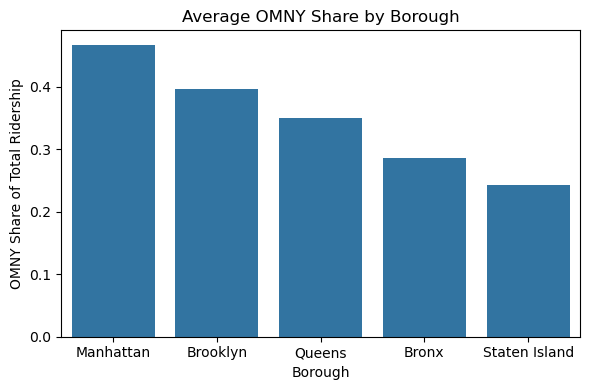

In [34]:
omny_summary_plot = (
    daily
    .groupby('borough')['omny_share']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'omny_share':'avg_omny_share'})
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=omny_summary_plot,
    x='borough',
    y='avg_omny_share'
)
plt.title('Average OMNY Share by Borough')
plt.xlabel('Borough')
plt.ylabel('OMNY Share of Total Ridership')
plt.tight_layout()
plt.show()

Payment behavior is also different across boroughs. One thing noticed though: Manhattan has both the highest per-station ridership and the highest OMNY share. Staten Island has the lowest ridership per station-day and also the lowest OMNY share.

Otherwise, we see that OMNY isn't evenly adopted. Some boroughs tend to lean more on the tap-to-pay than others. This is likely reflective of the different demographics of our riders. 

This also supports the idea that behavior in Manhattan is structrually different than, say Staten Island or the Bronx. There aren't just more riders, but there are different kinds of riders as well. This means that OMNY related features are worth keeping in.


### Statistical Interpretations

#### Weekday vs. Weekend Ridership

In [26]:
from scipy.stats import ttest_ind

weekday_riders = daily.loc[daily['is_weekend'] == False, 'ridership_total']
weekend_riders = daily.loc[daily['is_weekend'] == True,  'ridership_total']

t_stat, p_val = ttest_ind(weekday_riders, weekend_riders, equal_var=False)

print("Weekday vs Weekend t-test")
print("-------------------------")
print("Weekday mean:", weekday_riders.mean())
print("Weekend mean:", weekend_riders.mean())
print("Weekday std:", weekday_riders.std())
print("Weekend std:", weekend_riders.std())
print("Weekday n:", weekday_riders.shape[0])
print("Weekend n:", weekend_riders.shape[0])
print("t-statistic:", t_stat)
print("p-value:", p_val)

Weekday vs Weekend t-test
-------------------------
Weekday mean: 8231.028821515329
Weekend mean: 4869.998943928143
Weekday std: 11726.676060051712
Weekend std: 7568.528413651533
Weekday n: 225179
Weekend n: 89956
t-statistic: 95.16038290655163
p-value: 0.0


We ran a Welch t-test comparing weekday vs weekend ridership per station-day. Weekdays averaged about **8.2k** riders, weekends averaged about **4.9k** riders. The p-value was **0**, so we reject the null hypothesis that weekdays and weekends have the same mean ridership. Ridership is structurally higher on weekdays. This supports adding a weekend/weekday indicator (and possibly day-of-week) as a feature in the model.

#### Holiday vs. Non-Holiday Ridership

In [27]:
from scipy.stats import ttest_ind

holiday_riders    = daily.loc[daily['is_holiday_day'] == 1, 'ridership_total']
nonholiday_riders = daily.loc[daily['is_holiday_day'] == 0, 'ridership_total']

t_stat_h, p_val_h = ttest_ind(holiday_riders, nonholiday_riders, equal_var=False)

print("Holiday vs Non-Holiday t-test")
print("-----------------------------")
print("Holiday mean:", holiday_riders.mean())
print("Non-holiday mean:", nonholiday_riders.mean())
print("Holiday std:", holiday_riders.std())
print("Non-holiday std:", nonholiday_riders.std())
print("Holiday n:", holiday_riders.shape[0])
print("Non-holiday n:", nonholiday_riders.shape[0])
print("t-statistic:", t_stat_h)
print("p-value:", p_val_h)

Holiday vs Non-Holiday t-test
-----------------------------
Holiday mean: 4855.562044452443
Non-holiday mean: 7359.929883363704
Holiday std: 7480.087856444277
Non-holiday std: 10905.219296216292
Holiday n: 11113
Non-holiday n: 304022
t-statistic: -33.99848396672185
p-value: 1.0055206494165697e-242


We tested whether holidays behave like normal days. On holidays, stations average about **4.9k** riders per day. On non-holidays, it’s about **7.4k**. A Welch t-test gives a p-value near **0**, so we reject the null that holiday and non-holiday ridership are equal. This confirms that holidays are systematically lower-demand periods, not just noise, and supports including a holiday flag as its own feature so the model doesn’t over-predict on those days.

#### Borough Differences

In [28]:
from scipy.stats import f_oneway

# we have to build a list of ridership arrays, one per borough
groups = []
labels = []

for borough_name, subset in daily.groupby('borough'):
    groups.append(subset['ridership_total'])
    labels.append(borough_name)

f_stat, p_val = f_oneway(*groups)

print("Borough Test One-Way ANOVA")
print("-------------")
print("F-statistic:", f_stat)
print("p-value:", p_val)

borough_means = (
    daily
    .groupby('borough')['ridership_total']
    .mean()
    .sort_values(ascending=False)
)

borough_counts = (
    daily
    .groupby('borough')['ridership_total']
    .count()
    .sort_values(ascending=False)
)

borough_stds = (
    daily
    .groupby('borough')['ridership_total']
    .std()
    .sort_values(ascending=False)
)

print("\nAverage ridership_total by borough (mean):")
print(borough_means)
print("\nCount per borough:")
print(borough_counts)
print("\nStd per borough:")
print(borough_stds)

Borough Test One-Way ANOVA
-------------
F-statistic: 14935.953796216621
p-value: 0.0

Average ridership_total by borough (mean):
borough
Manhattan        13957.067359
Queens            5894.764402
Brooklyn          4483.635100
Bronx             3301.411216
Staten Island     2776.505092
Name: ridership_total, dtype: float64

Count per borough:
borough
Brooklyn         114837
Manhattan         90604
Queens            58116
Bronx             50105
Staten Island      1473
Name: ridership_total, dtype: int64

Std per borough:
borough
Manhattan        16791.959538
Queens            7259.958915
Brooklyn          4204.187624
Staten Island     2923.112719
Bronx             2526.024353
Name: ridership_total, dtype: float64


We ran a one-way ANOVA to test if mean ridership per station-day is the same across boroughs. Manhattan stations average ~**14k** riders per station-day, compared to ~**5.9k** in Queens, ~**4.5k** in Brooklyn, ~**3.3k** in the Bronx, and ~**2.8k** in Staten Island. The ANOVA p-value is **0**, so we reject the null that all boroughs have the same mean. Borough clearly matters, which supports encoding borough (or related station-location features) in the model.

#### OMNY Adoption by Borough

In [ ]:
from scipy.stats import f_oneway

# make sure omny_share exists
daily['omny_share'] = daily['ridership_omny'] / daily['ridership_total']

omny_groups = []
omny_labels = []

for borough_name, subset in daily.groupby('borough'):
    omny_groups.append(subset['omny_share'])
    omny_labels.append(borough_name)

f_stat_omny, p_val_omny = f_oneway(*omny_groups)

print("OMNY Share ANOVA by Borough")
print("---------------------------")
print("F-statistic:", f_stat_omny)
print("p-value:", p_val_omny)

omny_means = (
    daily
    .groupby('borough')['omny_share']
    .mean()
    .sort_values(ascending=False)
)
print("\nAverage OMNY share by borough:")
print(omny_means)

OMNY Share ANOVA by Borough
---------------------------
F-statistic: 22296.311788855004
p-value: 0.0

Average OMNY share by borough:
borough
Manhattan        0.466989
Brooklyn         0.396483
Queens           0.350491
Bronx            0.285874
Staten Island    0.242280
Name: omny_share, dtype: float64


We also tested whether OMNY payment share is consistent across boroughs. Manhattan shows the highest OMNY share (~**0.47**), and Staten Island shows the lowest (~**0.24**). The ANOVA p-value is **0**, which means we reject the null that OMNY usage is the same everywhere. This suggests rider behavior and payment preferences vary by borough. Features based on OMNY share may help capture changing usage patterns over time.

## Feature Selection and Engineering

#### 3.1 Problem Framing and Target

The goal going forward is to build a model that can forecast subway ridership at the **station-day** level.

* **Unit of Analysis:** one station on one calendar date
* **Target variable:** `ridership_total` for that station on that date
    * This captures total usage (MetroCard + OMNY), so it reflects actual demand at that station.
* **Why daily instead of hourly:** We aggregated hourly station records into daily totals per station. Daily demand shows clearer structure (weekday vs weekend, holidays, borough differences) and is more stable for forecasting than raw hourly noise.

Note on scale: some Manhattan stations average around ~**14k** riders per station-day, while some Bronx / Staten Island stations are closer to ~**3k** or below. That means the target is highly skewed and that a few stations are extremely busy compared to most others. For modeling, we may also try predicting `log1p(ridership_total)` to stabilize that skew and then convert predictions back.



#### 3.2 Calendar and Event Features

From the EDA, calendar effects were not just present — they were dominant.

**`day_of_week` / `is_weekend`**

* Average ridership per station-day on weekdays is ~**8.2k**, while weekends are ~**4.9k**.
* A t-test on weekday vs weekend ridership gave a p-value approximately equal to 0, so the difference is statistically significant.
* This means behavior is structurally different on weekends (lower commuter traffic).
* We will include:

  * a categorical `day_of_week` feature (Monday, Tuesday, …), and/or
  * a binary `is_weekend` feature.

**`is_holiday`**

* Holiday station-days average ~**4.9k** riders vs ~**7.4k** on non-holidays.
* The holiday vs non-holiday t-test also produced a p-value approximately equal to **0**, which tells us holidays are systematically lower-demand.
* We will include an `is_holiday` binary feature so the model doesn’t assume a holiday behaves like a normal Tuesday.

**`month` (or seasonal period)**

* Transit demand can shift by month due to weather, school schedules, tourism, etc.
* We will include `month` as a categorical feature to let the model learn broad seasonal patterns.

All of these features are “known in advance” (the calendar is known), so they are safe for forecasting without leaking future information.



#### 3.3 Location / Station Context Features

The EDA showed that ridership levels are not uniform across the city.

**`borough`**

* Manhattan stations average ~**13,957** riders per station-day.
* Staten Island stations average ~**2,777** riders per station-day.
* ANOVA across boroughs returned a p-value approximately equal to **0**, meaning borough is a real differentiator, not noise.
* We will include `borough` as a categorical feature (one-hot encoded). This lets the model learn different baseline levels for different parts of the city.

**`station_id` or station class**

* Some individual stations are huge hubs and others are neighborhood stops.
* If the model can handle high-cardinality categoricals, we can include `station_id` directly so each station has its own baseline.
* If not, we can engineer a simpler “station_type” feature (high-volume vs mid-volume vs low-volume) based on historical averages.

These features allow the model to understand “this station is generally busy” instead of trying to force the calendar features to explain everything.



#### 3.4 Rider Behavior Features

We also saw differences in *how* people pay, not just *how many* people ride.

**`omny_share` = `ridership_omny` / `ridership_total`**

* OMNY (tap-to-pay) adoption is not uniform. Manhattan’s OMNY share is ~**0.47**, Staten Island’s is ~**0.24**.
* ANOVA on OMNY share by borough also gave a p-value approximately equal to **0**.
* We will include `omny_share` as a numeric feature. This can help capture station profile / rider type (commuters vs occasional riders, tech adoption, tourist-heavy vs local-heavy, etc.).

This gives the model behavioral context, not just raw volume.



#### 3.5 Time-Series Memory / Recent History Features

Ridership today is highly related to ridership in the recent past. The model needs to “remember” recent behavior.

We will engineer lag and rolling features at the station level:

* **Lag features:**

  * `lag_1d`: ridership_total for the same station yesterday
  * `lag_7d`: ridership_total for the same station 7 days ago
  * `lag_14d`, `lag_28d`: to capture longer repeating patterns

  These capture short-term momentum (“Was this station busy yesterday?”) and recurring weekly structure (“What does this station usually look like on this weekday?”).

* **Rolling window features:**

  * 7-day rolling mean of ridership_total
  * 28-day rolling mean of ridership_total




#### 3.6 Data Treatment: Missingness, Edge Cases, Scaling

Before modeling, we need to make decisions about data cleanliness and consistency.

* **Missing values:**

  * Core columns (`station_id`, `borough`, `timestamp`, `ridership_total`) appear complete.
  * Derived features like `omny_share` can be undefined if `ridership_total` = 0 (division by zero).

    * If that row represents “no service / closed station,” we may drop it.
    * Otherwise, we can set `omny_share = 0` and add a flag like `zero_riders_flag = 1`.
  * For categoricals with missing values (e.g. unknown borough), we will fill with `"Unknown"` instead of dropping data.

* **Outliers / special events:**

  * Very low ridership days (holidays, storms, service disruptions) are real behavior, not just “bad data.”
  * We will keep them and use features like `is_holiday` and `is_weekend` so the model can learn to expect dips.
  * We will only remove rows that are clearly invalid (e.g. negative ridership).

* **Skew / scaling:**

  * The target is highly skewed because Manhattan hubs are way busier than most neighborhood stations.
  * For some models, we may predict `log1p(ridership_total)` instead of raw ridership_total, then convert back. This can stabilize training so giant stations don’t dominate the loss.



#### 3.7 Final Planned Feature Set

These are the features we plan to feed into the forecasting model:

* **Calendar / schedule features:**

  * `day_of_week` (categorical)
  * `is_weekend` (binary)
  * `is_holiday` (binary)
  * `month` (categorical)

* **Location / station context:**

  * `borough` (one-hot encoded)
  * possibly `station_id` or a derived `station_type` / “volume tier”

* **Behavioral:**

  * `omny_share` (OMNY riders / total riders)

* **Recent history / time-series memory:**

  * `lag_1d`, `lag_7d`, `lag_14d`, `lag_28d` of `ridership_total`
  * `rolling_7d_mean`, `rolling_28d_mean` of `ridership_total`
  * (optional) `rolling_7d_std` for recent volatility

* **Target to predict:**

  * `ridership_total` per station per day
  * (and potentially `log1p(ridership_total)` as an alternative modeling target)

These features are directly motivated by the findings in our EDA:

* weekday vs weekend is structurally different = `is_weekend`, `day_of_week`
* holidays are suppressed = `is_holiday`
* boroughs operate at different scales = `borough`
* rider behavior differs by borough = `omny_share`
* stations have memory and weekly patterns = lag and rolling features